# Entropic three-marginal Coulomb transport

This notebook generates `fig:multimarginal-coulomb-sinkhorn`.  It illustrates a one-dimensional softened analogue of the strictly-correlated-electrons problem: three identical marginals interact through the repulsive pairwise cost

$$
    c(x_1,x_2,x_3)=\sum_{1\leq r<s\leq 3}\frac{1}{\sqrt{(x_r-x_s)^2+\delta^2}}.
$$

The equal-marginal entropic multi-marginal problem is solved by tensor Sinkhorn scaling.  Each exported panel displays the pairwise marginal \(X_1,X_2\) together with glued marginal strips.  These strips make it visually explicit that the displayed two-particle law has the prescribed one-dimensional marginal on both axes.


In [1]:
from pathlib import Path
import os
import sys
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        FIGROOT = candidate.resolve()
        ROOT = FIGROOT.parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    figure_dir,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "multimarginal-coulomb-sinkhorn"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)

## Equal marginal and tensor Sinkhorn

The prescribed marginal is a two-bump Gaussian mixture with unequal masses and unequal widths.  This asymmetry makes the side strips informative: one can see both the narrow high-density component and the wider lower component.  To keep the Coulomb singularity finite on the grid, the cost uses a soft core \(\delta\).  For each \(\varepsilon\), the Gibbs tensor is scaled alternately along its three axes until the three marginals are equal to the prescribed density.


In [2]:
n = 53
x = np.linspace(-2.65, 2.65, n)
dx = x[1] - x[0]


def gaussian(mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)


rho = 0.62 * gaussian(-0.92, 0.24) + 0.38 * gaussian(1.02, 0.58)
a = rho * dx
a = a / a.sum()
rho = a / dx

X1, X2, X3 = np.meshgrid(x, x, x, indexing="ij")
soft_core = 0.12
C = (
    1.0 / np.sqrt((X1 - X2) ** 2 + soft_core**2)
    + 1.0 / np.sqrt((X1 - X3) ** 2 + soft_core**2)
    + 1.0 / np.sqrt((X2 - X3) ** 2 + soft_core**2)
)
base = a[:, None, None] * a[None, :, None] * a[None, None, :]


def tensor_sinkhorn(epsilon, *, max_iter=6000, tol=5e-10):
    K = base * np.exp(-(C - C.min()) / epsilon)
    u0 = np.ones(n)
    u1 = np.ones(n)
    u2 = np.ones(n)
    err = np.inf
    for it in range(max_iter):
        u0 = a / np.maximum((K * u1[None, :, None] * u2[None, None, :]).sum(axis=(1, 2)), 1e-300)
        u1 = a / np.maximum((K * u0[:, None, None] * u2[None, None, :]).sum(axis=(0, 2)), 1e-300)
        u2 = a / np.maximum((K * u0[:, None, None] * u1[None, :, None]).sum(axis=(0, 1)), 1e-300)
        if it % 25 == 0 or it == max_iter - 1:
            P = K * u0[:, None, None] * u1[None, :, None] * u2[None, None, :]
            err = max(
                np.abs(P.sum(axis=(1, 2)) - a).max(),
                np.abs(P.sum(axis=(0, 2)) - a).max(),
                np.abs(P.sum(axis=(0, 1)) - a).max(),
            )
            if err < tol:
                break
    P = K * u0[:, None, None] * u1[None, :, None] * u2[None, None, :]
    return P, it, err


epsilons = [0.06, 0.16, 2.00]
solutions = []
for eps in epsilons:
    P, it, err = tensor_sinkhorn(eps)
    P12 = P.sum(axis=2)
    row_err = np.abs(P12.sum(axis=1) - a).max()
    col_err = np.abs(P12.sum(axis=0) - a).max()
    solutions.append((eps, P12, it, err, row_err, col_err))
    print(
        f"epsilon={eps:.2f}, iterations={it}, tensor error={err:.2e}, "
        f"P12 row/col errors=({row_err:.2e}, {col_err:.2e})"
    )


epsilon=0.06, iterations=550, tensor error=4.72e-10, P12 row/col errors=(4.72e-10, 2.35e-10)
epsilon=0.16, iterations=250, tensor error=1.39e-10, P12 row/col errors=(1.39e-10, 6.86e-11)
epsilon=2.00, iterations=25, tensor error=2.32e-11, P12 row/col errors=(2.32e-11, 9.97e-12)


## Exported panels

The diagonal in each pairwise projection corresponds to collisions between two particles and is strongly penalized by the Coulomb interaction.  Smaller \(\varepsilon\) gives a sharper avoidance pattern; larger \(\varepsilon\) blurs the pairwise law toward the independent reference.  The red and blue side strips show the prescribed marginal, while the thin dark curves are the marginals obtained by summing the displayed pairwise plan.


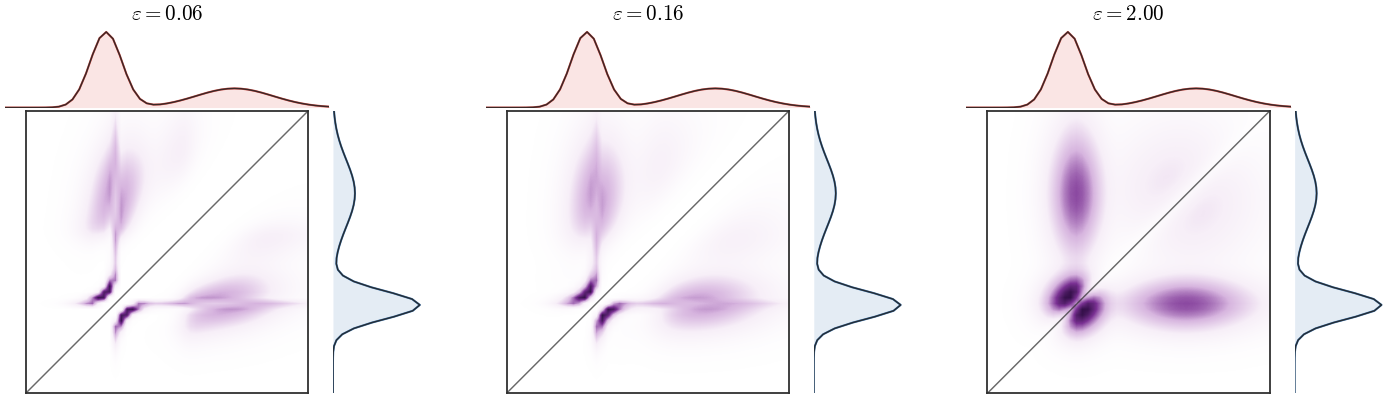

In [3]:
plan_cmap = LinearSegmentedColormap.from_list(
    "coulomb_pairwise_plan",
    ["#ffffff", "#f7eff8", "#d7b5df", VIOLET, "#35104a"],
)

xlim = (-2.45, 2.45)
side_scale = 1.12 * rho.max()


def remove_side_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor("white")


def box_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.68)
        spine.set_edgecolor("#303030")


def plan_image(P12):
    return (P12 / max(P12.max(), 1e-300)) ** 0.38


def draw_pairwise_panel(fig, subspec, P12, *, title=None, linewidth=0.86):
    row_density = P12.sum(axis=1) / dx
    col_density = P12.sum(axis=0) / dx

    gs = subspec.subgridspec(
        2,
        2,
        width_ratios=[1.0, 0.30],
        height_ratios=[0.30, 1.0],
        wspace=0.018,
        hspace=0.018,
    )
    ax_top = fig.add_subplot(gs[0, 0])
    ax_corner = fig.add_subplot(gs[0, 1])
    ax = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])

    remove_side_axes(ax_top)
    remove_side_axes(ax_corner)
    remove_side_axes(ax_right)

    ax.imshow(
        plan_image(P12).T,
        origin="lower",
        extent=[x[0], x[-1], x[0], x[-1]],
        cmap=plan_cmap,
        interpolation="bilinear",
        vmin=0.0,
        vmax=1.0,
        aspect="equal",
    )
    ax.plot(xlim, xlim, color="#2f2f2f", lw=0.55, alpha=0.72)
    ax.set_xlim(*xlim)
    ax.set_ylim(*xlim)
    box_axis(ax)

    ax_top.fill_between(x, 0, rho, color=RED, alpha=0.12, linewidth=0)
    ax_top.plot(x, rho, color=RED, lw=linewidth, alpha=0.82)
    ax_top.plot(x, row_density, color="#202020", lw=0.56, alpha=0.86)
    ax_top.set_xlim(*xlim)
    ax_top.set_ylim(0.0, side_scale)
    if title is not None:
        ax_top.set_title(title, fontsize=8.0, pad=0.8)

    ax_right.fill_betweenx(x, 0, rho, color=BLUE, alpha=0.12, linewidth=0)
    ax_right.plot(rho, x, color=BLUE, lw=linewidth, alpha=0.82)
    ax_right.plot(col_density, x, color="#202020", lw=0.56, alpha=0.86)
    ax_right.set_ylim(*xlim)
    ax_right.set_xlim(0.0, side_scale)


def draw_pairwise_pdf(P12, path):
    fig = plt.figure(figsize=(2.35, 2.35))
    outer = fig.add_gridspec(1, 1, left=0.02, right=0.985, bottom=0.02, top=0.985)
    draw_pairwise_panel(fig, outer[0], P12)
    save_pdf(fig, path, pad_inches=0.012)
    plt.close(fig)


filenames = ["epsilon-small.pdf", "epsilon-medium.pdf", "epsilon-large.pdf"]
for filename, (_, P12, _, _, _, _) in zip(filenames, solutions):
    draw_pairwise_pdf(P12, OUT / filename)
    shutil.copy2(OUT / filename, ARXIV_OUT / f"{NAME}--{filename}")


def make_thumbnail(path):
    fig = plt.figure(figsize=(7.45, 2.28))
    outer = fig.add_gridspec(1, 3, left=0.01, right=0.99, bottom=0.025, top=0.88, wspace=0.13)
    for k, (eps, P12, _, _, _, _) in enumerate(solutions):
        draw_pairwise_panel(fig, outer[k], P12, title=rf"$\varepsilon={eps:.2f}$", linewidth=0.78)
    fig.savefig(path, dpi=190, bbox_inches="tight", pad_inches=0.025)
    plt.close(fig)


make_thumbnail(THUMB)
display(Image(filename=str(THUMB)))


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

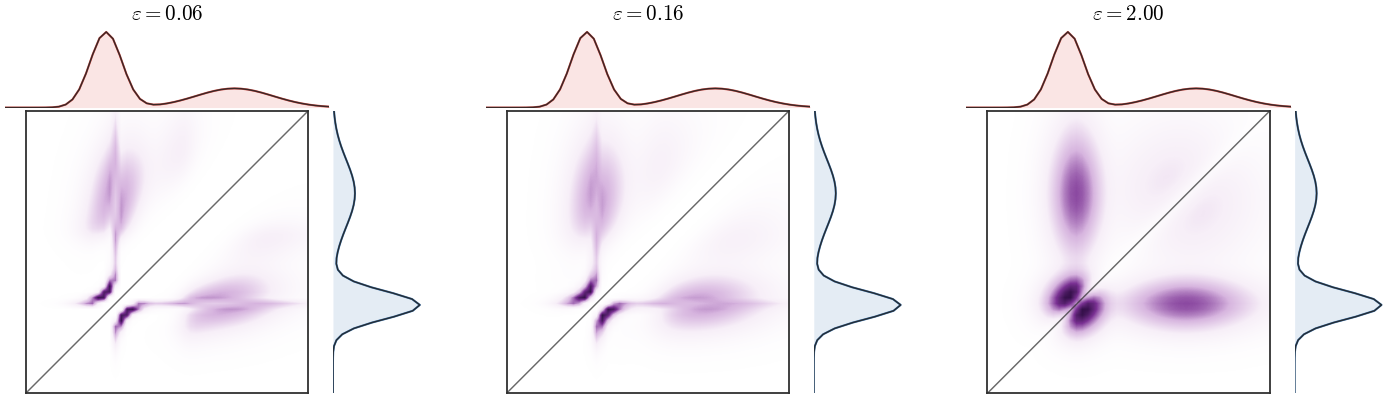

In [4]:
display(Image(filename=str(THUMB)))